# Model Analysis Suite



In [137]:
# PSL imports,
import os

# Third-party imports.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors 
import seaborn as sns
import scipy
from sklearn.metrics.pairwise import pairwise_distances

# Notebook imports,
from IPython.display import clear_output
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import HBox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Load Data

In [4]:
# Specifying redshift,
redshift = 0.0

# Loading grids,
DMD_grid = np.load(f"DMD_grid_z{redshift}.npy")
DMV_grid = np.load(f"DMV_grid_z{redshift}.npy")
Ne_grid = np.load(f"Ne_grid_z{redshift}.npy")
T_grid = np.load(f"T_grid_z{redshift}.npy")

# Loading model predictions,
Ne_pred = np.load(f"(DMP-Ne-v1.5-z{redshift})_pred.npy")
T_pred = np.load(f"(DMP-T-v1.5-z{redshift})_pred.npy")

# Compute Emissivity Field

In [89]:
# PARAMETERS,
PIXEL_SCALE = 25/256 # Mpc/h
MIN_THRESHOLD = 1e-44 # Actual Units
i = 0

def compute_emissivity(n_e, T):
    return (1.42*1e-27)*(n_e**2)*(T**0.5)

def update_emissivity_plot(i):
  """Function called whenever the slider is changed."""

  # Creating figure,
  fig, axes = plt.subplots(1, 4, figsize=(15, 5))

  # Plotting DM grid,
  data = np.log10(DMD_grid[i])
  img_data = axes[0].imshow(data, cmap="inferno")
  axes[0].set_title("DM Density")
  axes[0].set_xlabel("Mpc/$h$")
  axes[0].set_ylabel("Mpc/$h$")
  fig.colorbar(img_data, orientation="horizontal", label = r"$(M_{\odot}/h)/(Mpc/h)^3$ (Logarithmic Scale)")

  # Plotting emissivity grid (ground truth),
  truth = np.log10(emissivity_grid[i])
  img_truth = axes[1].imshow(truth, cmap="inferno")
  axes[1].set_title("Emissivity (Ground Truth)")
  axes[1].set_xlabel("Mpc/$h$")
  axes[1].set_ylabel("Mpc/$h$")
  fig.colorbar(img_truth, orientation="horizontal", label = "ergs $s^{-1}$ c$m^{-3}$ (Logarithmic Scale)")

  # Plotting emissivity grid (prediction),
  pred = np.log10(emissivity_grid_pred[i])
  img_pred = axes[2].imshow(pred, cmap="inferno")
  axes[2].set_title("Emissivity (Model Prediction)")
  axes[2].set_xlabel("Mpc/$h$")
  axes[2].set_ylabel("Mpc/$h$")
  fig.colorbar(img_pred, orientation="horizontal", label = "ergs $s^{-1}$ c$m^{-3}$ (Logarithmic Scale)")

  # Plotting residue,
  ratio = emissivity_grid_pred[i]/emissivity_grid[i]
  img_ratio = axes[3].imshow(ratio, cmap="bwr", norm=colors.LogNorm(vmin=0.001, vmax=1000))
  axes[3].set_title("Ratio")
  axes[3].set_xlabel("Mpc/$h$")
  axes[3].set_ylabel("Mpc/$h$")
  fig.colorbar(img_ratio, orientation="horizontal")

  # Updating xticks and yticks,
  for ax in axes:

    xticks = ax.get_xticks()[1:-1]
    yticks = ax.get_yticks()[1:-1]

    # Converting into physical units,
    xtick_labels = [f"{x * PIXEL_SCALE:.0f}" for x in xticks]
    ytick_labels = [f"{y * PIXEL_SCALE:.0f}" for y in yticks]

    # Setting ticks,
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)

  # Displaying plot,
  plt.tight_layout()
  plt.show()

# Computing emissivity,
emissivity_grid = compute_emissivity(n_e=Ne_grid, T=T_grid)
emissivity_grid_pred = compute_emissivity(n_e=Ne_pred, T=T_grid)

# Creating slider,
slider1 = widgets.IntSlider(value=i, min=0, max=100, step=1, description="Slice")

# Display interactive output,
interactive_plot = widgets.interactive_output(update_emissivity_plot, {"i":slider1})

# Display slider and plot,
display(slider1, interactive_plot)

IntSlider(value=0, description='Slice')

Output()

# Cluster Finding Algorithm

In [262]:
def CCL(field, threshold):
    """Uses a standard two-pass binary connected component labelling (CCL) algorithm to indentify and label clusters on a grid based on a threshold value given."""

    # Create a binary mask of overdense regions,
    binary_mask = field > threshold

    # Label connected regions (FoF-like approach for grid-based data),
    labeled_array, num_features = scipy.ndimage.label(binary_mask)

    # Computing the centres of mass for each cluster,
    cluster_centres = scipy.ndimage.center_of_mass(binary_mask, labeled_array, np.arange(1, num_features + 1))   

    # Converting coordinates to integer values,
    cluster_centres_int = []
    for i, cluster_centre in enumerate(cluster_centres):
       cluster_centre_int = (int(cluster_centre[0]), int(cluster_centre[1]), int(cluster_centre[2]))
       cluster_centres_int.append(cluster_centre_int)
    
    # Converting to NumPy,
    cluster_centres = np.array(cluster_centres)

    return labeled_array, np.array(cluster_centres_int)

"""PARAMETERS"""
THRESHOLD = 5e-34 # Actual units
PIXEL_SCALE = 25/256 # Mpc/h
i = 0 # Inital Slice

# Computing emissivity,
emissivity_grid = compute_emissivity(n_e=Ne_grid, T=T_grid)
emissivity_grid_pred = compute_emissivity(n_e=Ne_pred, T=T_grid)

# Finding clusters,
labeled_array, cluster_centres = CCL(field=emissivity_grid, threshold=THRESHOLD)
labeled_array_pred, cluster_centres_pred = CCL(field=emissivity_grid_pred, threshold=THRESHOLD)
print(f"Target Cluster Number: {len(cluster_centres)}, Prediction Cluster Number: {len(cluster_centres_pred)}")

def update_cluster_plot(i):
  """Function called whenever the slider is changed."""

  # Creating figure,
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Plotting emissivity grid (ground truth),
  truth = np.log10(emissivity_grid[i])
  img_truth = axes[0].imshow(truth, cmap="inferno")
  axes[0].set_title("Emissivity (Ground Truth)")
  axes[0].set_xlabel("Mpc/$h$")
  axes[0].set_ylabel("Mpc/$h$")
  fig.colorbar(img_truth, orientation="vertical", label = "ergs $s^{-1}$ c$m^{-3}$ (Logarithmic Scale)")

  # Plotting emissivity grid (prediction),
  pred = np.log10(emissivity_grid_pred[i])
  img_pred = axes[1].imshow(pred, cmap="inferno")
  axes[1].set_title("Emissivity (Model Prediction)")
  axes[1].set_xlabel("Mpc/$h$")
  axes[1].set_ylabel("Mpc/$h$")
  fig.colorbar(img_pred, orientation="vertical", label = "ergs $s^{-1}$ c$m^{-3}$ (Logarithmic Scale)")

  # Drawing X marks for the cluster centers at given slice,
  for center in cluster_centres:
      z, y, x = center
      if z == i:
          axes[0].plot(x, y, "x", color="white", markersize=8, markeredgewidth=2)

  for center in cluster_centres_pred:
      z, y, x = center
      if z == i:
          axes[1].plot(x, y, "x", color="white", markersize=8, markeredgewidth=2)

  # Updating xticks and yticks,
  for ax in axes:

    xticks = ax.get_xticks()[1:-1]
    yticks = ax.get_yticks()[1:-1]

    # Converting into physical units,
    xtick_labels = [f"{x * PIXEL_SCALE:.0f}" for x in xticks]
    ytick_labels = [f"{y * PIXEL_SCALE:.0f}" for y in yticks]

    # Setting ticks,
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)

  # Displaying plot,
  plt.tight_layout()
  plt.show()

# Computing emissivity,
emissivity_grid = compute_emissivity(n_e=Ne_grid, T=T_grid)
emissivity_grid_pred = compute_emissivity(n_e=Ne_pred, T=T_grid)

# Creating slider,
slider1 = widgets.IntSlider(value=i, min=0, max=100, step=1, description="Slice")

# Display interactive output,
interactive_plot = widgets.interactive_output(update_cluster_plot, {"i":slider1})

# Display slider and plot,
display(slider1, interactive_plot)

Target Cluster Number: 1494, Prediction Cluster Number: 1426


IntSlider(value=0, description='Slice')

Output()

In [256]:
"""PARAMETERS"""
PIXEL_SCALE = 25/256 # Mpc/h
NEIGHBOURHOOD_SIZE = 10
i = NEIGHBOURHOOD_SIZE # Inital Slice Number
j = 200 # Inital Cluster Number

def update_zoomedcluster_plot(i, j):
  """Function called whenever the slider is changed."""

  # Creating figure,
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Extracting zoomed view,
  halo_loc = cluster_centres[j]
  cluster_neighbourhood_emissivity = emissivity_grid[(halo_loc[0] - NEIGHBOURHOOD_SIZE):(halo_loc[0] + NEIGHBOURHOOD_SIZE),
                                                     (halo_loc[1] - NEIGHBOURHOOD_SIZE):(halo_loc[1] + NEIGHBOURHOOD_SIZE),
                                                     (halo_loc[2] - NEIGHBOURHOOD_SIZE):(halo_loc[2] + NEIGHBOURHOOD_SIZE)]
  
  cluster_neighbourhood_emissivity_pred = emissivity_grid_pred[(halo_loc[0] - NEIGHBOURHOOD_SIZE):(halo_loc[0] + NEIGHBOURHOOD_SIZE),
                                                               (halo_loc[1] - NEIGHBOURHOOD_SIZE):(halo_loc[1] + NEIGHBOURHOOD_SIZE),
                                                               (halo_loc[2] - NEIGHBOURHOOD_SIZE):(halo_loc[2] + NEIGHBOURHOOD_SIZE)]
  
  # ZOOMED: Target,
  halo_target_img = np.log10(cluster_neighbourhood_emissivity[i])
  img_pred = axes[0].imshow(halo_target_img, cmap="inferno")
  axes[0].set_title("Halo (Target)")
  axes[0].set_xlabel("Mpc/$h$")
  axes[0].set_ylabel("Mpc/$h$")
  fig.colorbar(img_pred , orientation="vertical")

  # ZOOMED: Prediction,
  halo_pred_img = np.log10(cluster_neighbourhood_emissivity_pred[i])
  img_pred = axes[1].imshow(halo_pred_img, cmap="inferno")
  axes[1].set_title("Halo (Prediction)")
  axes[1].set_xlabel("Mpc/$h$")
  axes[1].set_ylabel("Mpc/$h$")
  fig.colorbar(img_pred , orientation="vertical")

  # Updating xticks and yticks,
  for ax in axes:

    xticks = ax.get_xticks()[1:-1]
    yticks = ax.get_yticks()[1:-1]

    # Converting into physical units,
    xtick_labels = [f"{x * PIXEL_SCALE:.0f}" for x in xticks]
    ytick_labels = [f"{y * PIXEL_SCALE:.0f}" for y in yticks]

    # Setting ticks,
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)

  # Displaying plot,
  plt.tight_layout()
  plt.show()

# Computing emissivity,
emissivity_grid = compute_emissivity(n_e=Ne_grid, T=T_grid)
emissivity_grid_pred = compute_emissivity(n_e=Ne_pred, T=T_grid)

# Creating sliders,
slider1 = widgets.IntSlider(value=i, min=0, max=(2*NEIGHBOURHOOD_SIZE + 1), step=1, description="Slice")
slider2 = widgets.IntSlider(value=j, min=0, max=cluster_centres.shape[0], step=1, description="Cluster Number")

# Display interactive output,
interactive_plot = widgets.interactive_output(update_zoomedcluster_plot, {"i":slider1, "j":slider2})

# Display slider and plot,
clear_output(wait=False)
display(slider1, slider2, interactive_plot)

IntSlider(value=10, description='Slice', max=21)

IntSlider(value=200, description='Cluster Number', max=1494)

Output()

# Scaling Relations

IntSlider(value=185, description='Cluster Number', max=1494)

Output()

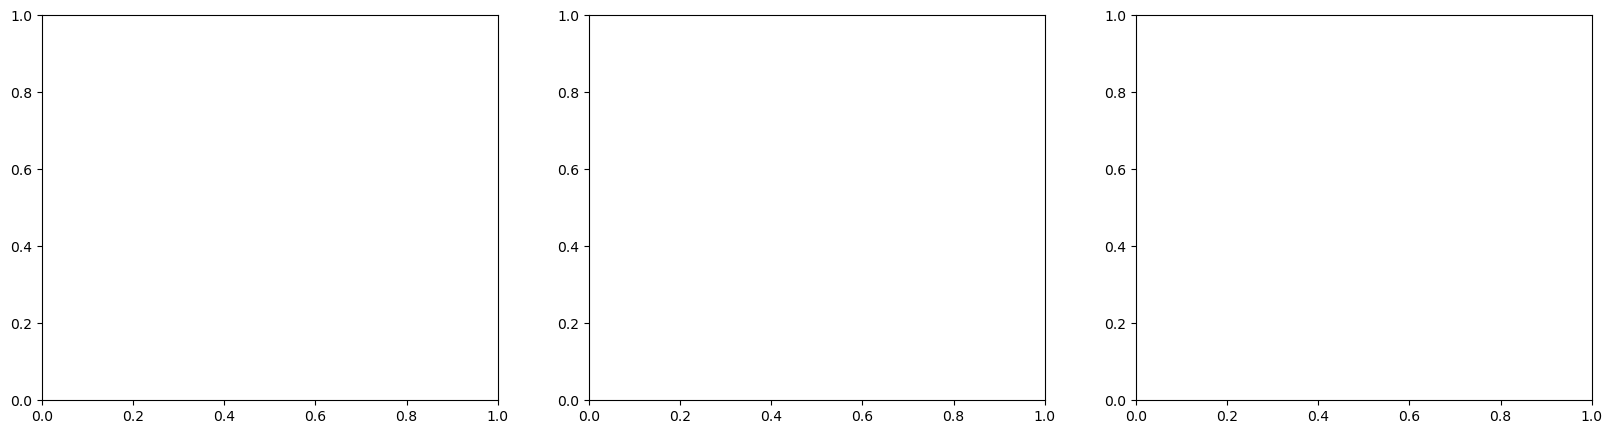

In [ ]:
def extract_pixels(field, centre_coord, neighbourhood_size):
    """Helper function to extract the nearby pixels around a cluster location."""
    return field[(centre_coord[0] - neighbourhood_size):(centre_coord[0] + neighbourhood_size),
                 (centre_coord[1] - neighbourhood_size):(centre_coord[1] + neighbourhood_size),
                 (centre_coord[2] - neighbourhood_size):(centre_coord[2] + neighbourhood_size)]

# Parameters,
j = 185
CLUSTER_SIZE = 3
NEIGHBOURHOOD_SIZE = 15

def update_scaling_plot(j):

    # Extracting jth cluster location,
    cluster_loc = cluster_centres[j]

    # Creating figure,
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Extracting pixel values,
    cn_T = extract_pixels(field=T_grid, centre_coord=cluster_loc, neighbourhood_size=CLUSTER_SIZE)
    cn_Ne = extract_pixels(field=Ne_grid, centre_coord=cluster_loc, neighbourhood_size=CLUSTER_SIZE)
    cn_Ne_pred = extract_pixels(field=Ne_pred, centre_coord=cluster_loc, neighbourhood_size=CLUSTER_SIZE)
    cn_T_pred = extract_pixels(field=T_pred, centre_coord=cluster_loc, neighbourhood_size=CLUSTER_SIZE)
    cn_DMD = extract_pixels(field=DMD_grid, centre_coord=cluster_loc, neighbourhood_size=CLUSTER_SIZE)

    # Flattening and taking the natural log,
    cluster_DMD_vals = np.log10(cn_DMD.flatten())
    cluster_Ne_vals = np.log10(cn_Ne.flatten())
    cluster_Ne_predvals = np.log10(cn_Ne_pred.flatten())
    cluster_T_vals = np.log10(cn_T.flatten())
    cluster_T_predvals = np.log10(cn_T_pred.flatten())

    # Computing lines of best fit,
    m, b = np.polyfit(cluster_DMD_vals, cluster_Ne_vals, deg=1)
    m_pred, b_pred = np.polyfit(cluster_DMD_vals, cluster_Ne_predvals, deg=1)

    # Plotting main graphs,
    axes[0].scatter(cluster_DMD_vals, cluster_Ne_vals, color = "black", label = "CAMELS-IllustrisTNG", alpha=0.5)
    axes[0].scatter(cluster_DMD_vals, cluster_Ne_predvals, color = "blue", label = "CosmoMap", alpha=0.5)
    axes[0].plot(cluster_DMD_vals, cluster_DMD_vals*m + b, color = "black")
    axes[0].plot(cluster_DMD_vals, cluster_DMD_vals*m_pred + b_pred, color = "blue")
    axes[0].set_xlabel("""Dark Matter Density $Log_{10}(\\rho_{DM}/M)$""")
    axes[0].set_ylabel("Electron Number Density $Log_{10}(n_e/h^2 cm^2)$")
    axes[0].set_title("Gas–Dark Matter Density Relation")
    axes[0].legend(loc="upper left")

    axes[1].scatter(cluster_DMD_vals, cluster_T_vals, color = "black", label = "CAMELS-IllustrisTNG", alpha=0.8)
    axes[1].scatter(cluster_DMD_vals, cluster_T_predvals, color = "blue", label = "CosmoMap", alpha=0.8)
    sns.kdeplot(x=cluster_DMD_vals, y=cluster_T_vals, ax=axes[1], levels=5, color="black", label="CAMELS KDE", fill=True, alpha=0.35)
    sns.kdeplot(x=cluster_DMD_vals, y=cluster_T_predvals, ax=axes[1], levels=5, color="blue", label="CosmoMap KDE", fill=True, alpha=0.35)
    axes[1].set_xlabel("""Dark Matter Density $Log_{10}(\\rho_{DM}/M)$""")
    axes[1].set_ylabel("Temperature $Log_{10}(T/K)$")
    axes[1].set_title("Gas Temperature–Dark Matter Density Relation")
    axes[1].legend(loc="upper left")

    # Plotting visualisation images,
    ax_main = axes[2]
    ax_main.set_title("Visualisation")
    ax_main.axis('off') 

    # Creating positions for images,
    positions = [(0.05, 0.55), (0.55, 0.55), (0.05, 0.05), (0.55, 0.05)]
    titles = ["Temperature (Ground Truth)", "Temperature (Prediction)", "Electron Number Density (Ground Truth)", "Electron Number Density (Prediction)"]

    # Extracting pixel values,
    cn_T = extract_pixels(field=T_grid, centre_coord=cluster_loc, neighbourhood_size=NEIGHBOURHOOD_SIZE)
    cn_Ne = extract_pixels(field=Ne_grid, centre_coord=cluster_loc, neighbourhood_size=NEIGHBOURHOOD_SIZE)
    cn_Ne_pred = extract_pixels(field=Ne_pred, centre_coord=cluster_loc, neighbourhood_size=NEIGHBOURHOOD_SIZE)
    cn_T_pred = extract_pixels(field=T_pred, centre_coord=cluster_loc, neighbourhood_size=NEIGHBOURHOOD_SIZE)
    cn_DMD = extract_pixels(field=DMD_grid, centre_coord=cluster_loc, neighbourhood_size=NEIGHBOURHOOD_SIZE)
    grids = [cn_T, cn_T_pred, cn_Ne, cn_Ne_pred]
    
    # Rendering images,
    for grid_idx, (x, y) in enumerate(positions):
        ax_inset = inset_axes(ax_main, width="40%", height="40%", loc="lower left",
                              bbox_to_anchor=(x, y, 1, 1), bbox_transform=ax_main.transAxes, borderpad=0)

        img = np.log10(grids[grid_idx][NEIGHBOURHOOD_SIZE])
        img_obj = ax_inset.imshow(img, origin="lower")
        ax_inset.set_title(titles[grid_idx], fontsize=8)
        ax_inset.axis("off")

    # Display plot,
    plt.show()

# Creating sliders,
slider = widgets.IntSlider(value=j, min=0, max=cluster_centres.shape[0], step=1, description="Cluster Number")

# Display interactive output,
interactive_plot = widgets.interactive_output(update_scaling_plot, {"j":slider})
clear_output(wait=False)
display(slider, interactive_plot)

# The Cluster Correlation Function

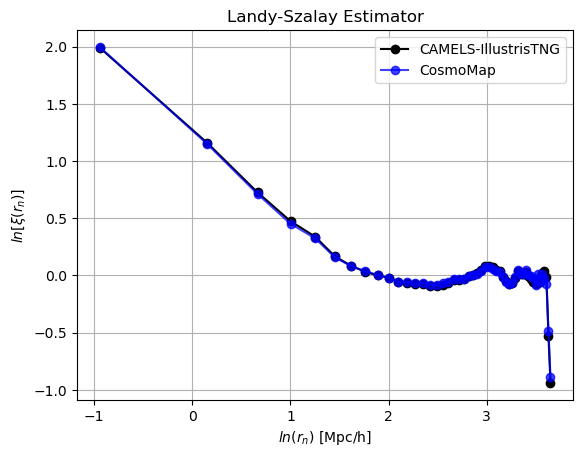

In [265]:
def compute_LSE(clusters, bins, size_factor, length_scale, max_distance):
    """Helper function to compute the Landy-Szalay estimator (LSE) for the cluster correlation function
    (CCF)."""

    # Creating random distribution,
    random_cluster_centres = []
    for i in range(size_factor*cluster_centres.shape[0]):
        random_cluster_centre = np.random.randint(low=0, high=256, size=3)
        random_cluster_centres.append(random_cluster_centre)
    random_cluster_centres = np.array(random_cluster_centres)

    # Compute all pairwise distances,
    DD_pairwise_distances = sklearn.metrics.pairwise_distances(cluster_centres).flatten()
    RR_pairwise_distances = sklearn.metrics.pairwise_distances(random_cluster_centres).flatten()
    DR_pairwise_distances = sklearn.metrics.pairwise_distances(cluster_centres, random_cluster_centres).flatten()

    # Create the width of the bins,
    bin_edges = np.linspace(start=DD_pairwise_distances.min(), stop=DD_pairwise_distances.max(), num=(bins+1))
    bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])*PIXEL_SCALE

    # Computing histograms,
    DD, _ = np.histogram(DD_pairwise_distances, bins=bin_edges)
    RR, _ = np.histogram(RR_pairwise_distances, bins=bin_edges)
    DR, _ = np.histogram(DR_pairwise_distances, bins=bin_edges)

    # Normalising histrograms,
    n_data, n_random = cluster_centres.shape[0], random_cluster_centres.shape[0]
    norm_DD = DD/(n_data*(n_data - 1)/2)
    norm_RR = RR/(n_random*(n_random-1)/2)
    norm_DR = DR/(n_data*n_random)

    # Computing Landy-Szalay estimator,
    epsilon_LS = (norm_DD - 2*norm_DR + norm_RR)/norm_RR

    return epsilon_LS, bin_centers

# Parameters,
N_BINS = 50
SIZE_FACTOR = 5
PIXEL_SCALE = 25/256 # Mpc/h
MAX_SEP = 30 # Mpc/h

# Computing Landy-Szalay estimators,
epsilon_LS, bin_centers = compute_LSE(clusters=cluster_centres, bins=N_BINS, size_factor=SIZE_FACTOR, length_scale=PIXEL_SCALE, max_distance=MAX_SEP)
epsilon_LS_pred, _ = compute_LSE(clusters=cluster_centres_pred, bins=N_BINS, size_factor=SIZE_FACTOR, length_scale=PIXEL_SCALE, max_distance=MAX_SEP)

# Plotting,
plt.plot(np.log(bin_centers), np.log(epsilon_LS), marker='o', color="black", label="CAMELS-IllustrisTNG")
plt.plot(np.log(bin_centers), np.log(epsilon_LS_pred), marker='o', color="blue", label="CosmoMap", alpha=0.75)
plt.xlabel("$ln(r_n)$ [Mpc/h]")
plt.ylabel("$ln[ξ(r_n)]$")
plt.title("Landy-Szalay Estimator")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()